In [1]:
from sklearn.model_selection import train_test_split
import numpy as np
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt


import pickle
import pandas as pd

with open('./../data/interim/X_train.pkl', 'rb') as file:
    X_train = pickle.load(file)
with open('./../data/interim/X_test.pkl', 'rb') as file:
    X_test = pickle.load(file)

# получить тестовую переменную
df = pd.read_csv('../data/interim/cleaned_comments.csv')
X = df['comment']
y = df['label']
_, _, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print('Классы:', le.classes_)
print(pd.Series(y_train).value_counts())

Классы: ['INSULT' 'NORMAL' 'OBSCENITY' 'THREAT']
label
NORMAL       162941
INSULT        22853
THREAT         9421
OBSCENITY      3409
Name: count, dtype: int64


In [2]:
# подгрузить самодельные фичи по индексам из pkl (гарантируем тот же сплит)
HANDCRAFTED_COLS = [
    'length_sym', 'length_words', 'av_word_len',
    'swearing', 'has_positive_emoji', 'has_negative_emoji', 'has_obscene_emoji',
    'imperative', '2nd_prsn_count', '3nd_prsn_count',
    'adj_count', 'vocative', 'expr_punct',
    # is_normal исключён — потенциальная утечка данных
]

X_com_train  = df.loc[X_train.index, 'comment'].fillna('')
X_com_test   = df.loc[X_test.index,  'comment'].fillna('')
X_hand_train = df.loc[X_train.index, HANDCRAFTED_COLS].astype(float)
X_hand_test  = df.loc[X_test.index,  HANDCRAFTED_COLS].astype(float)

## Стратегия 1: TF-IDF (sparse) -> CatBoost

- Word (1,2)-граммы на лемматизированных токенах из X_train — ловит лексику и биграммы
- Char (2,4)-граммы на сыром тексте — ловит матерные корни, опечатки
- Handcrafted признаки → sparse → `scipy.sparse.hstack`

In [3]:
# Word (1,2)-граммы на лемматизированных токенах (X_train из pkl)
tfidf_word = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=12_000,
    sublinear_tf=True,
    min_df=5,
)
X_word_train = tfidf_word.fit_transform(X_train)
X_word_test  = tfidf_word.transform(X_test)

# Char (2,4)-граммы на сыром тексте — ловит опечатки и матерные корни
tfidf_char = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 4),
    max_features=5_000,
    sublinear_tf=True,
    min_df=10,
)
X_char_train = tfidf_char.fit_transform(X_com_train)
X_char_test  = tfidf_char.transform(X_com_test)

# Sparse handcrafted
X_hand_sp_train = sp.csr_matrix(X_hand_train.values)
X_hand_sp_test  = sp.csr_matrix(X_hand_test.values)

X_tr_s1 = sp.hstack([X_word_train, X_char_train, X_hand_sp_train])
X_te_s1 = sp.hstack([X_word_test,  X_char_test,  X_hand_sp_test])

print(f'Train: {X_tr_s1.shape}, Test: {X_te_s1.shape}')

Train: (198624, 17013), Test: (49657, 17013)


In [4]:
model_s1 = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=5,
    auto_class_weights='Balanced',
    eval_metric='TotalF1:average=Macro',
    random_seed=42,
    verbose=15,
)
model_s1.fit(
    X_tr_s1, y_train_enc,
    eval_set=(X_te_s1, y_test_enc),
    early_stopping_rounds=30,
)

0:	learn: 0.5897412	test: 0.5852015	best: 0.5852015 (0)	total: 3.02s	remaining: 15m 2s
15:	learn: 0.6430871	test: 0.6396326	best: 0.6396326 (15)	total: 41.1s	remaining: 12m 9s
30:	learn: 0.6951986	test: 0.6886231	best: 0.6886231 (30)	total: 1m 18s	remaining: 11m 23s
45:	learn: 0.7279666	test: 0.7191839	best: 0.7191839 (45)	total: 1m 53s	remaining: 10m 26s
60:	learn: 0.7439346	test: 0.7335253	best: 0.7335253 (60)	total: 2m 24s	remaining: 9m 25s
75:	learn: 0.7561900	test: 0.7449384	best: 0.7449384 (75)	total: 2m 58s	remaining: 8m 46s
90:	learn: 0.7662064	test: 0.7563185	best: 0.7563185 (90)	total: 3m 30s	remaining: 8m 2s
105:	learn: 0.7770811	test: 0.7633810	best: 0.7633810 (105)	total: 4m	remaining: 7m 20s
120:	learn: 0.7848169	test: 0.7688639	best: 0.7688639 (120)	total: 4m 30s	remaining: 6m 40s
135:	learn: 0.7960518	test: 0.7817708	best: 0.7817708 (135)	total: 4m 59s	remaining: 6m 1s
150:	learn: 0.8025287	test: 0.7888611	best: 0.7888611 (150)	total: 5m 30s	remaining: 5m 26s
165:	learn

CatBoostClassifier(auto_class_weights='Balanced', depth=5, eval_metric='TotalF1:average=Macro', iterations=300, learning_rate=0.1, random_seed=42, verbose=15)

In [5]:
# еще чуть чуть пообучать

model_s1_continued = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=5,
    auto_class_weights='Balanced',
    eval_metric='TotalF1:average=Macro',
    random_seed=42,
    verbose=15,
)
model_s1_continued.fit(
    X_tr_s1, y_train_enc,
    eval_set=(X_te_s1, y_test_enc),
    early_stopping_rounds=30,
    init_model=model_s1,  # продолжаем с того места где остановились
)


0:	learn: 0.8428732	test: 0.8228347	best: 0.8228347 (0)	total: 2.74s	remaining: 9m 5s
15:	learn: 0.8450146	test: 0.8243395	best: 0.8243395 (15)	total: 38.6s	remaining: 7m 24s
30:	learn: 0.8476496	test: 0.8262559	best: 0.8263295 (28)	total: 1m 8s	remaining: 6m 15s
45:	learn: 0.8494368	test: 0.8288939	best: 0.8290470 (44)	total: 1m 43s	remaining: 5m 46s
60:	learn: 0.8509455	test: 0.8284029	best: 0.8290470 (44)	total: 2m 17s	remaining: 5m 13s
75:	learn: 0.8529553	test: 0.8296848	best: 0.8296848 (75)	total: 2m 56s	remaining: 4m 47s
90:	learn: 0.8544613	test: 0.8315069	best: 0.8315069 (90)	total: 3m 36s	remaining: 4m 18s
105:	learn: 0.8560663	test: 0.8317070	best: 0.8317070 (105)	total: 4m 9s	remaining: 3m 41s
120:	learn: 0.8576398	test: 0.8325061	best: 0.8325985 (119)	total: 4m 39s	remaining: 3m 2s
135:	learn: 0.8593479	test: 0.8329108	best: 0.8329108 (135)	total: 5m 9s	remaining: 2m 25s
150:	learn: 0.8604424	test: 0.8336524	best: 0.8336527 (149)	total: 5m 37s	remaining: 1m 49s
165:	learn:

CatBoostClassifier(auto_class_weights='Balanced', depth=5, eval_metric='TotalF1:average=Macro', iterations=200, learning_rate=0.1, random_seed=42, verbose=15)

              precision    recall  f1-score   support

      INSULT       0.85      0.69      0.76      5713
      NORMAL       0.97      0.95      0.96     40736
   OBSCENITY       0.47      0.83      0.60       852
      THREAT       0.54      0.83      0.65      2356

    accuracy                           0.91     49657
   macro avg       0.71      0.82      0.74     49657
weighted avg       0.93      0.91      0.92     49657

F1 macro:      0.7433
ROC-AUC (OvR): 0.9622


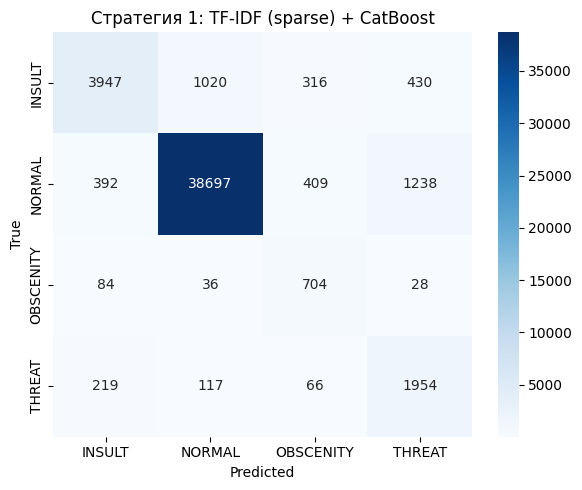

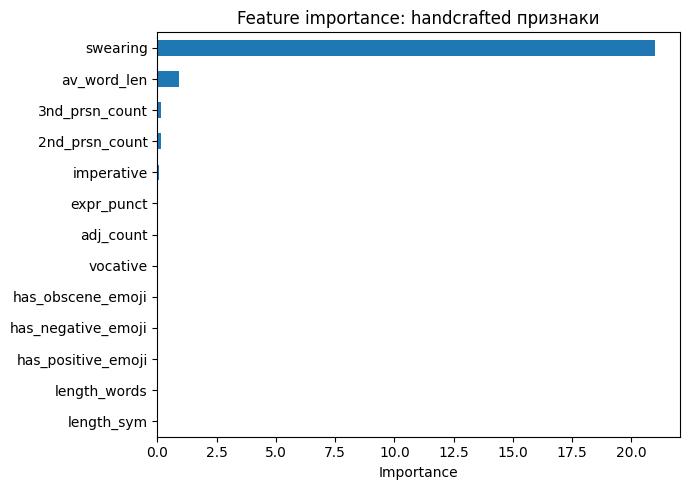

In [6]:
y_pred_s1  = model_s1.predict(X_te_s1).flatten()
y_proba_s1 = model_s1.predict_proba(X_te_s1)

print(classification_report(y_test_enc, y_pred_s1, target_names=le.classes_))
print(f'F1 macro:      {f1_score(y_test_enc, y_pred_s1, average="macro"):.4f}')
print(f'ROC-AUC (OvR): {roc_auc_score(y_test_enc, y_proba_s1, multi_class="ovr", average="macro"):.4f}')

cm = confusion_matrix(y_test_enc, y_pred_s1)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Стратегия 1: TF-IDF (sparse) + CatBoost')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Feature importance для хэндкрафтед признаков
# Они идут последними в hstack: [word_tfidf | char_tfidf | handcrafted]
importances = model_s1.get_feature_importance()
hand_importances = importances[-len(HANDCRAFTED_COLS):]

fi = pd.Series(hand_importances, index=HANDCRAFTED_COLS).sort_values(ascending=True)
plt.figure(figsize=(7, 5))
fi.plot(kind='barh')
plt.title('Feature importance: handcrafted признаки')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 2: TF-IDF + LSA (TruncatedSVD) + CatBoost

Большое TF-IDF пространство сжимается SVD до ~150 плотных компонент.  
Интересно проверить, сильно ли упадет качество

UPD: качество упало очень сильно

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

# TF-IDF
tfidf_word_s2 = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    min_df=3,
)
tfidf_char_s2 = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 4),
    max_features=30_000,
    sublinear_tf=True,
    min_df=5,
)

X_word_tr_s2 = tfidf_word_s2.fit_transform(X_train)
X_word_te_s2 = tfidf_word_s2.transform(X_test)

X_char_tr_s2 = tfidf_char_s2.fit_transform(X_com_train)
X_char_te_s2 = tfidf_char_s2.transform(X_com_test)

# объединить признаки в матрицу до svd
X_tfidf_train = sp.hstack([X_word_tr_s2, X_char_tr_s2])
X_tfidf_test  = sp.hstack([X_word_te_s2, X_char_te_s2])

print(f'TF-IDF before SVD: {X_tfidf_train.shape}')

# SVD
svd = TruncatedSVD(n_components=150, random_state=42)
X_lsa_train = svd.fit_transform(X_tfidf_train)
X_lsa_test  = svd.transform(X_tfidf_test)

print(f'LSA after SVD:     {X_lsa_train.shape}')
print(f'Explained variance ratio: {svd.explained_variance_ratio_.sum():.3f}')

# о
X_tr_s2 = np.hstack([X_lsa_train, X_hand_train.values])
X_te_s2 = np.hstack([X_lsa_test,  X_hand_test.values])

print(f'Итоговый train: {X_tr_s2.shape}')

TF-IDF before SVD: (198624, 80000)
LSA after SVD:     (198624, 150)
Explained variance ratio: 0.151
Итоговый train: (198624, 163)


In [28]:
model_s2 = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    auto_class_weights='Balanced',
    eval_metric='TotalF1:average=Macro',
    random_seed=42,
    verbose=100
)
model_s2.fit(
    X_tr_s2, y_train_enc,
    eval_set=(X_te_s2, y_test_enc),
    early_stopping_rounds=50,
)

0:	learn: 0.5403110	test: 0.5381083	best: 0.5381083 (0)	total: 57.3ms	remaining: 57.3s
100:	learn: 0.7396897	test: 0.7144346	best: 0.7146659 (98)	total: 5.55s	remaining: 49.4s
200:	learn: 0.7904081	test: 0.7349459	best: 0.7367654 (188)	total: 10.4s	remaining: 41.4s
300:	learn: 0.8229431	test: 0.7461465	best: 0.7471372 (296)	total: 15.1s	remaining: 35s
400:	learn: 0.8467343	test: 0.7515835	best: 0.7526906 (398)	total: 19.7s	remaining: 29.4s
500:	learn: 0.8696724	test: 0.7556160	best: 0.7570453 (479)	total: 24.5s	remaining: 24.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7570452732
bestIteration = 479

Shrink model to first 480 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=6, eval_metric='TotalF1:average=Macro', iterations=1000, learning_rate=0.1, random_seed=42, verbose=100)

              precision    recall  f1-score   support

      INSULT       0.71      0.71      0.71      5713
      NORMAL       0.97      0.92      0.95     40736
   OBSCENITY       0.25      0.61      0.36       852
      THREAT       0.55      0.79      0.65      2356

    accuracy                           0.89     49657
   macro avg       0.62      0.76      0.67     49657
weighted avg       0.91      0.89      0.90     49657

F1 macro:      0.6671


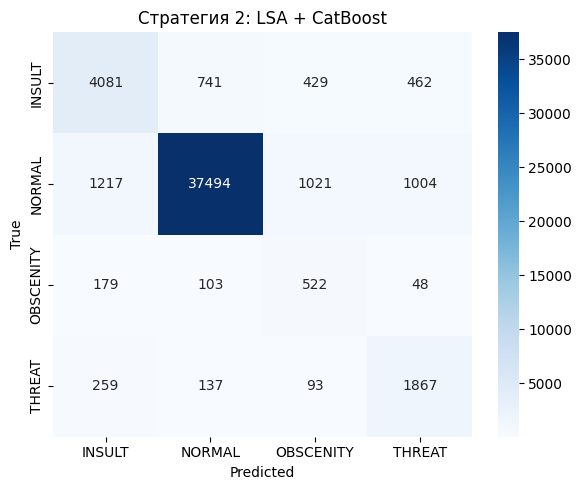

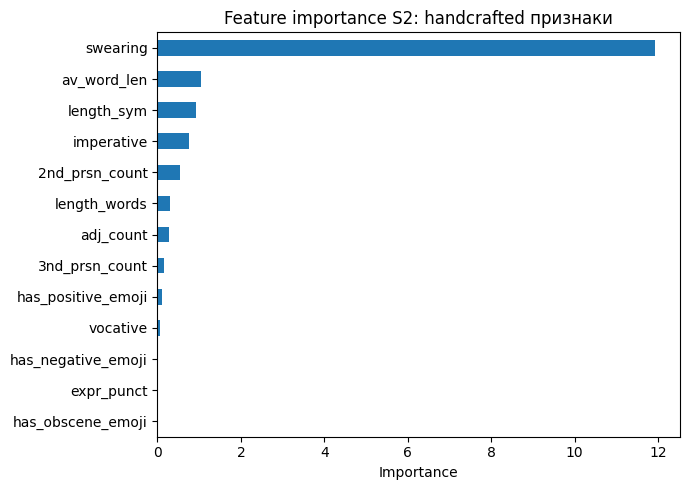

In [30]:
y_pred_s2  = model_s2.predict(X_te_s2).flatten()
y_proba_s2 = model_s2.predict_proba(X_te_s2)

print(classification_report(y_test_enc, y_pred_s2, target_names=le.classes_))
print(f'F1 macro:      {f1_score(y_test_enc, y_pred_s2, average="macro"):.4f}')

cm = confusion_matrix(y_test_enc, y_pred_s2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Стратегия 2: LSA + CatBoost')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Feature importance для хэндкрафтед признаков
importances_s2 = model_s2.get_feature_importance()
hand_importances_s2 = importances_s2[-len(HANDCRAFTED_COLS):]

fi_s2 = pd.Series(hand_importances_s2, index=HANDCRAFTED_COLS).sort_values(ascending=True)
plt.figure(figsize=(7, 5))
fi_s2.plot(kind='barh')
plt.title('Feature importance S2: handcrafted признаки')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 3 эмбеддинги

Тут, как и у линейных моделей, получилось качество ниже, чем в случае tf-idf. Возможно из-за того, что для бустинга пришлось усреднять эмбеддинги слов в один эмбеддинг предложения.

In [7]:
from gensim.models import KeyedVectors
import tqdm

def vectorize(text, model):
    vectors = []
    sentences = []
    for i in text:
        if isinstance(i, str):
            sentences.append(i.split('\t'))
        else:
            sentences.append([])
    for sent in tqdm.tqdm(sentences):
        vec = []
        for word in sent:
            if word not in model:
                vec.append(np.zeros(model.vector_size))
            else:
                vec.append(model[word])
        if vec:
            vectors.append(np.mean(vec, axis=0))
        else:
            vectors.append(np.zeros(model.vector_size))
    return vectors


data_parsed = pd.read_csv("../data/interim/comments_parsed.csv")
model_path = "../data/models/araneum_upos_skipgram.vec"
w2v = KeyedVectors.load_word2vec_format(model_path, binary=False)

comment_vectors = vectorize(data_parsed['lemma_pos'], w2v)
comment_vectors = np.stack(np.array(comment_vectors))

df_vectors = pd.DataFrame(comment_vectors, columns=[f"w2v_{i + 1}" for i in range(comment_vectors.shape[1])])

100%|██████████| 248281/248281 [00:02<00:00, 99151.29it/s]


Train: (198624, 313), Test: (49657, 313)
0:	learn: 0.5330679	test: 0.5270824	best: 0.5270824 (0)	total: 321ms	remaining: 5m 21s
100:	learn: 0.7405870	test: 0.7185233	best: 0.7190156 (98)	total: 10.4s	remaining: 1m 32s
200:	learn: 0.7821522	test: 0.7369204	best: 0.7383729 (191)	total: 20.5s	remaining: 1m 21s
300:	learn: 0.8116852	test: 0.7402751	best: 0.7416415 (284)	total: 30.5s	remaining: 1m 10s
400:	learn: 0.8321213	test: 0.7451766	best: 0.7451766 (400)	total: 40.7s	remaining: 1m
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7451766461
bestIteration = 400

Shrink model to first 401 iterations.
              precision    recall  f1-score   support

      INSULT       0.69      0.71      0.70      5713
      NORMAL       0.98      0.90      0.94     40736
   OBSCENITY       0.29      0.68      0.40       852
      THREAT       0.36      0.70      0.48      2356

    accuracy                           0.86     49657
   macro avg       0.58      0.75      0.63     4

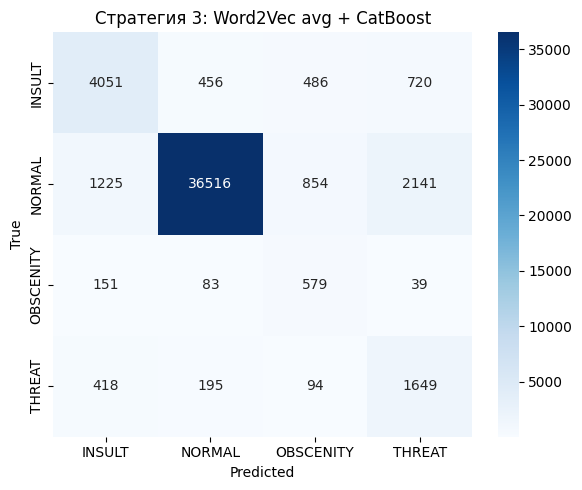

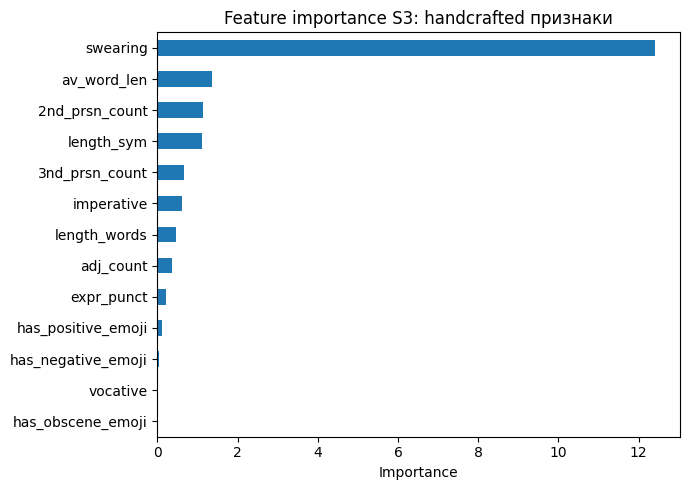

In [8]:
# Берём W2V векторы по тем же индексам что X_train/X_test из pkl
X_w2v_train = df_vectors.loc[X_train.index].values
X_w2v_test  = df_vectors.loc[X_test.index].values

# Конкатенируем с хэндкрафтед признаками
X_tr_s3 = np.hstack([X_w2v_train, X_hand_train.values])
X_te_s3 = np.hstack([X_w2v_test,  X_hand_test.values])

print(f'Train: {X_tr_s3.shape}, Test: {X_te_s3.shape}')

model_s3 = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    auto_class_weights='Balanced',
    eval_metric='TotalF1:average=Macro',
    random_seed=42,
    verbose=100,
)
model_s3.fit(
    X_tr_s3, y_train_enc,
    eval_set=(X_te_s3, y_test_enc),
    early_stopping_rounds=50,
)

y_pred_s3  = model_s3.predict(X_te_s3).flatten()
y_proba_s3 = model_s3.predict_proba(X_te_s3)

print(classification_report(y_test_enc, y_pred_s3, target_names=le.classes_))
print(f'F1 macro:      {f1_score(y_test_enc, y_pred_s3, average="macro"):.4f}')
print(f'ROC-AUC (OvR): {roc_auc_score(y_test_enc, y_proba_s3, multi_class="ovr", average="macro"):.4f}')

cm = confusion_matrix(y_test_enc, y_pred_s3)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Стратегия 3: Word2Vec avg + CatBoost')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Feature importance для хэндкрафтед (последние len(HANDCRAFTED_COLS) позиций)
importances_s3 = model_s3.get_feature_importance()
hand_importances_s3 = importances_s3[-len(HANDCRAFTED_COLS):]

fi_s3 = pd.Series(hand_importances_s3, index=HANDCRAFTED_COLS).sort_values(ascending=True)
plt.figure(figsize=(7, 5))
fi_s3.plot(kind='barh')
plt.title('Feature importance S3: handcrafted признаки')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [9]:
# подбор гиперпараметров

import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix

def objective(trial):
    params = {
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 10, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 3),
        "random_strength": trial.suggest_float("random_strength", 0, 3),

        "auto_class_weights": "Balanced",
        "eval_metric": "TotalF1:average=Macro",
        "loss_function": "MultiClass",

        "random_seed": 42,
        "verbose": 100,
    }

    print(f"\n{'='*15} Trial {trial.number} {'='*15}")

    model = CatBoostClassifier(**params)

    model.fit(
        X_tr_s3, y_train_enc,
        eval_set=(X_te_s3, y_test_enc),
        early_stopping_rounds=50,
        verbose=100
    )

    best_score = model.get_best_score()["validation"]["TotalF1:average=Macro"]

    print(f"Trial {trial.number} | F1_macro: {best_score:.4f}")

    return best_score


study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
)

study.optimize(objective, n_trials=40, show_progress_bar=True)

print("\nЛучшие параметры:")
print(study.best_params)

print(f"\nЛучший F1_macro: {study.best_value:.4f}")

/Users/kirilldesatnicenko/Jupyter/toxic-comments/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-01 15:20:26,445] A new study created in memory with name: no-name-f83b962d-13bd-4fd5-a57f-a4d9b2e224f3
  0%|          | 0/40 [00:00<?, ?it/s]


=============== Trial 0 ===============
0:	learn: 0.5289272	test: 0.5255015	best: 0.5255015 (0)	total: 346ms	remaining: 5m 45s
100:	learn: 0.7437119	test: 0.6983839	best: 0.6995553 (97)	total: 36s	remaining: 5m 20s
200:	learn: 0.7873892	test: 0.7249137	best: 0.7249137 (200)	total: 1m 11s	remaining: 4m 42s
300:	learn: 0.8185918	test: 0.7314188	best: 0.7314188 (300)	total: 1m 45s	remaining: 4m 4s
400:	learn: 0.8467232	test: 0.7336293	best: 0.7347059 (380)	total: 2m 18s	remaining: 3m 26s
500:	learn: 0.8675273	test: 0.7350389	best: 0.7363401 (464)	total: 2m 50s	remaining: 2m 50s


Best trial: 0. Best value: 0.73634:   2%|▎         | 1/40 [02:55<1:54:08, 175.60s/it]

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7363400937
bestIteration = 464

Shrink model to first 465 iterations.
Trial 0 | F1_macro: 0.7363
[I 2026-04-01 15:23:22,048] Trial 0 finished with value: 0.7363400937493925 and parameters: {'learning_rate': 0.0446796183862553, 'depth': 8, 'l2_leaf_reg': 0.028615208914435503, 'bagging_temperature': 1.715373950724148, 'random_strength': 2.123040451863419}. Best is trial 0 with value: 0.7363400937493925.

=============== Trial 1 ===============
0:	learn: 0.4661440	test: 0.4678848	best: 0.4678848 (0)	total: 74.9ms	remaining: 1m 14s
100:	learn: 0.6928564	test: 0.6791348	best: 0.6809137 (94)	total: 6.46s	remaining: 57.5s
200:	learn: 0.7177175	test: 0.7057174	best: 0.7074616 (194)	total: 12.6s	remaining: 49.9s
300:	learn: 0.7385274	test: 0.7222675	best: 0.7230022 (299)	total: 18.6s	remaining: 43.3s
400:	learn: 0.7516331	test: 0.7306203	best: 0.7306203 (400)	total: 24.6s	remaining: 36.8s
500:	learn: 0.7598443	test: 0.7344592	b

Best trial: 1. Best value: 0.745225:   5%|▌         | 2/40 [03:53<1:07:19, 106.29s/it]

...

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7355315141
bestIteration = 222

Shrink model to first 223 iterations.
Trial 37 | F1_macro: 0.7355
[I 2026-04-01 15:49:44,793] Trial 37 finished with value: 0.7355315141378463 and parameters: {'learning_rate': 0.08625326545279786, 'depth': 8, 'l2_leaf_reg': 0.4969796814531829, 'bagging_temperature': 1.1740929778297493, 'random_strength': 1.5891773311268675}. Best is trial 14 with value: 0.7530705320643132.

=============== Trial 38 ===============
0:	learn: 0.4661440	test: 0.4678848	best: 0.4678848 (0)	total: 78.6ms	remaining: 1m 18s
100:	learn: 0.7264709	test: 0.7141222	best: 0.7141222 (100)	total: 6.62s	remaining: 58.9s
200:	learn: 0.7611450	test: 0.7335356	best: 0.7338578 (199)	total: 12.8s	remaining: 50.9s
300:	learn: 0.7812019	test: 0.7389968	best: 0.7414398 (297)	total: 18.7s	remaining: 43.4s


Best trial: 14. Best value: 0.753071:  98%|█████████▊| 39/40 [29:41<00:41, 41.17s/it]

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7429740824
bestIteration = 323

Shrink model to first 324 iterations.
Trial 38 | F1_macro: 0.7430
[I 2026-04-01 15:50:08,104] Trial 38 finished with value: 0.7429740823888138 and parameters: {'learning_rate': 0.16048367509948375, 'depth': 4, 'l2_leaf_reg': 0.9382994338791173, 'bagging_temperature': 0.9848052113540984, 'random_strength': 1.8963709781725955}. Best is trial 14 with value: 0.7530705320643132.

=============== Trial 39 ===============
0:	learn: 0.4661440	test: 0.4678848	best: 0.4678848 (0)	total: 65ms	remaining: 1m 4s
100:	learn: 0.6483153	test: 0.6404322	best: 0.6404322 (100)	total: 6.45s	remaining: 57.4s
200:	learn: 0.6890929	test: 0.6786634	best: 0.6786634 (200)	total: 13s	remaining: 51.6s
300:	learn: 0.7068184	test: 0.6968100	best: 0.6977159 (294)	total: 19.5s	remaining: 45.2s
400:	learn: 0.7159487	test: 0.7032407	best: 0.7054326 (388)	total: 25.7s	remaining: 38.3s
500:	learn: 0.7249870	test: 0.7146910	

Best trial: 14. Best value: 0.753071: 100%|██████████| 40/40 [30:43<00:00, 46.09s/it]

999:	learn: 0.7557215	test: 0.7339972	best: 0.7340120 (982)	total: 1m 1s	remaining: 0us

bestTest = 0.7340119612
bestIteration = 982

Shrink model to first 983 iterations.
Trial 39 | F1_macro: 0.7340
[I 2026-04-01 15:51:09,952] Trial 39 finished with value: 0.7340119611866202 and parameters: {'learning_rate': 0.026354593069377194, 'depth': 4, 'l2_leaf_reg': 1.6762410417437748, 'bagging_temperature': 1.1370034265116307, 'random_strength': 1.4617792642480005}. Best is trial 14 with value: 0.7530705320643132.

Лучшие параметры:
{'learning_rate': 0.1334811207757012, 'depth': 5, 'l2_leaf_reg': 0.10405810768110052, 'bagging_temperature': 0.6184449861651499, 'random_strength': 1.045229846220747}

Лучший F1_macro: 0.7531


0:	learn: 0.4861730	test: 0.4840039	best: 0.4840039 (0)	total: 109ms	remaining: 1m 48s
100:	learn: 0.7379365	test: 0.7184941	best: 0.7184941 (100)	total: 8.26s	remaining: 1m 13s
200:	learn: 0.7777808	test: 0.7352230	best: 0.7360948 (193)	total: 15.4s	remaining: 1m 1s
300:	learn: 0.8044819	test: 0.7403527	best: 0.7414227 (289)	total: 22.6s	remaining: 52.5s
400:	learn: 0.8260002	test: 0.7464667	best: 0.7464667 (400)	total: 29.6s	remaining: 44.3s
500:	learn: 0.8439260	test: 0.7479193	best: 0.7486289 (497)	total: 36.9s	remaining: 36.7s
600:	learn: 0.8594272	test: 0.7504591	best: 0.7507488 (582)	total: 44.2s	remaining: 29.3s
700:	learn: 0.8705875	test: 0.7521544	best: 0.7526789 (688)	total: 51.3s	remaining: 21.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7530705321
bestIteration = 727

Shrink model to first 728 iterations.

=== FINAL MODEL REPORT ===
              precision    recall  f1-score   support

      INSULT       0.70      0.74      0.72      5713
      N

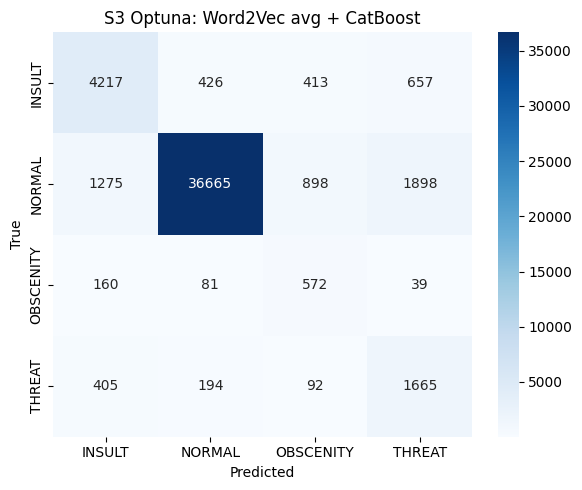

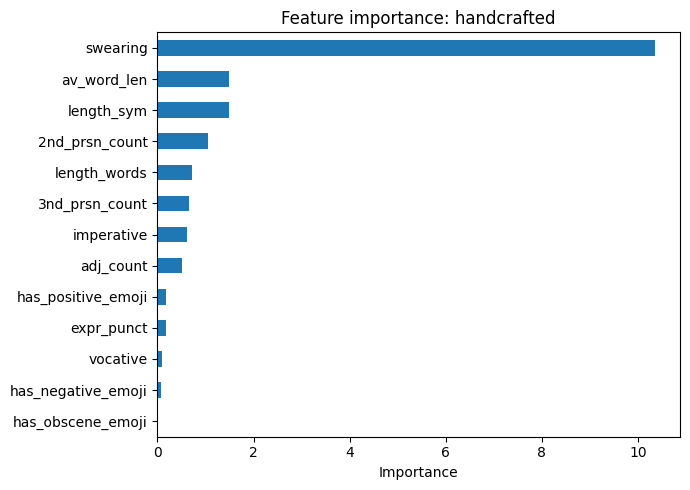

In [10]:
# лучшая модель, метрики
best_params = study.best_params

final_model = CatBoostClassifier(
    **best_params,
    iterations=1000,
    auto_class_weights='Balanced',
    eval_metric='TotalF1:average=Macro',
    loss_function='MultiClass',
    random_seed=42,
    verbose=100,
)

final_model.fit(
    X_tr_s3, y_train_enc,
    eval_set=(X_te_s3, y_test_enc),
    early_stopping_rounds=50,
)

y_pred = final_model.predict(X_te_s3).flatten()
y_proba = final_model.predict_proba(X_te_s3)

print("\n=== FINAL MODEL REPORT ===")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))
print(f'F1 macro:      {f1_score(y_test_enc, y_pred, average="macro"):.4f}')
print(f'ROC-AUC (OvR): {roc_auc_score(y_test_enc, y_proba, multi_class="ovr", average="macro"):.4f}')

cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('S3 Optuna: Word2Vec avg + CatBoost')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


importances = final_model.get_feature_importance()
hand_importances = importances[-len(HANDCRAFTED_COLS):]

fi = pd.Series(hand_importances, index=HANDCRAFTED_COLS).sort_values(ascending=True)

plt.figure(figsize=(7, 5))
fi.plot(kind='barh')
plt.title('Feature importance: handcrafted')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()